# Taller de Evaluación Parcial 02: Clasificación EMG

**Universidad EAFIT**

**Profesor:** Jorge Iván Padilla Buriticá

**Integrantes:** Kevin Quiroz & Carlos Mazo

---

## Detección de Fatiga Muscular en Ciclismo

En este notebook se desarrolla el problema de clasificación del dataset **Muscle Fatigue Cycling**, siguiendo las etapas del workshop:

1. Análisis preliminar del problema
2. Extracción de características a partir de ventanas de 1 segundo
3. EDA sobre la nueva base de datos
4. Procesamiento de datos
5. Entrenamiento y comparación de modelos
6. Evaluación final del mejor modelo
7. Prueba con muestra artificial

## Instalación de dependencias

In [1]:
# Ejecutar solo si está en Google Colab
!pip install datasets -q

## Importaciones

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from scipy.signal import welch

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 100)
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Análisis Preliminar del Problema

### 1a. Carga del dataset y preprocesamiento del target

El dataset contiene señales EMG de 8 músculos de la pierna dominante durante sprints en bicicleta. El target original tiene 3 etiquetas (0, 1, 2); se recodifica a binario:
- `0` → Condición normal
- `1` → Desgaste muscular (etiquetas 1 y 2 del original se colapsan en 1)

La recodificación aplica la regla **cualquier valor ≥ 1 → 1**, más robusta que un `replace` puntual, garantizando la binarización independientemente del número de niveles originales.

In [3]:
# Carga desde HuggingFace
dataset = load_dataset('YominE/Muscle_Fatigue_Cycling')
df = dataset['train'].to_pandas()

print('Forma del dataset:', df.shape)
print('\nPrimeras filas:')
df.head()

README.md: 0.00B [00:00, ?B/s]

Patient1.csv:   0%|          | 0.00/114M [00:00<?, ?B/s]

Patient2.csv:   0%|          | 0.00/290M [00:00<?, ?B/s]

Patient3.csv:   0%|          | 0.00/95.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3002137 [00:00<?, ? examples/s]

Forma del dataset: (3002137, 10)

Primeras filas:


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


In [4]:
# Verificar valores únicos del target original
print('Target original - valores únicos:', df['Target'].unique())
print('Distribución:\n', df['Target'].value_counts())

# Recodificación robusta: cualquier etiqueta >= 1 → 1 (desgaste)
df['Target'] = df['Target'].apply(lambda x: 1 if x >= 1 else 0)

print('\nTarget binario - valores únicos:', df['Target'].unique())
print('Nueva distribución:\n', df['Target'].value_counts())

Target original - valores únicos: [0 1 2]
Distribución:
 Target
0    2127600
1     631200
2     243337
Name: count, dtype: int64

Target binario - valores únicos: [0 1]
Nueva distribución:
 Target
0    2127600
1     874537
Name: count, dtype: int64


### 1b. Clasificación de variables

| Variable | Tipo | Descripción |
|---|---|---|
| `Time` | Numérica continua | Marca temporal en segundos |
| `Right Rectus femoris` … `Left Gastrocnemius lateralis` | Numérica continua | Amplitud de la señal EMG (valores del dispositivo de adquisición) |
| `Target` | Binaria (0/1) | Variable objetivo: 0 = condición normal, 1 = desgaste muscular |

In [5]:
print('Tipos de datos:\n', df.dtypes)
print('\nEstadísticos descriptivos:')
df.describe()

Tipos de datos:
 Time                                float64
Right Rectus femoris                float64
Left Gluteus maximus                float64
Left Gastrocnemius medialis         float64
Left Semitendinosus                 float64
Left Biceps femoris caput longus    float64
Right Vastus medialis               float64
Right Tibialis anterior             float64
Left Gastrocnemius lateralis        float64
Target                                int64
dtype: object

Estadísticos descriptivos:


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
count,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06,3.002137e+06
mean,6.385404e+02,3.818719e-10,-5.484116e-09,1.607046e-08,6.232624e-09,2.408926e-08,-2.482363e-08,4.634169e-10,-5.008274e-08,2.913048e-01
std,4.855156e+02,4.322670e-02,2.126250e-02,4.680434e-02,3.235313e-02,4.256358e-02,7.176269e-02,5.702359e-02,5.926507e-02,4.543637e-01
min,0.000000e+00,-8.433421e-01,-1.117295e+00,-1.749318e+00,-1.575973e+00,-7.503011e-01,-1.216622e+00,-1.304432e+00,-1.199719e+00,0.000000e+00
25%,2.501780e+02,-9.712520e-03,-3.884910e-03,-8.921014e-03,-6.285701e-03,-8.235582e-03,-9.509088e-03,-1.332585e-02,-1.391587e-02,0.000000e+00
50%,5.003560e+02,4.047832e-05,-1.482451e-05,9.786492e-05,-1.267264e-04,1.626615e-04,1.187206e-04,-1.495369e-04,6.502335e-04,0.000000e+00
75%,9.910640e+02,1.018903e-02,3.919922e-03,9.312195e-03,6.089190e-03,9.009457e-03,1.112872e-02,1.315710e-02,1.687481e-02,1.000000e+00
max,1.741598e+03,9.920845e-01,1.063230e+00,1.614778e+00,8.685851e-01,8.429890e-01,1.079527e+00,1.336625e+00,9.400506e-01,1.000000e+00


In [6]:
# Determinar frecuencia de muestreo a partir de la columna Time
dt = df['Time'].diff().dropna().median()
fs = int(round(1 / dt))
print(f'Intervalo de muestreo (dt): {dt:.4f} s')
print(f'Frecuencia de muestreo (fs): {fs} Hz')
print(f'Duración total del registro: {df["Time"].max():.1f} s')

Intervalo de muestreo (dt): 0.0010 s
Frecuencia de muestreo (fs): 1000 Hz
Duración total del registro: 1741.6 s


### 1c. Visualización de una porción de las señales en el tiempo

Se grafican los primeros 5 segundos para una identificación inicial del comportamiento de la señal antes de construir el nuevo dataset de características.

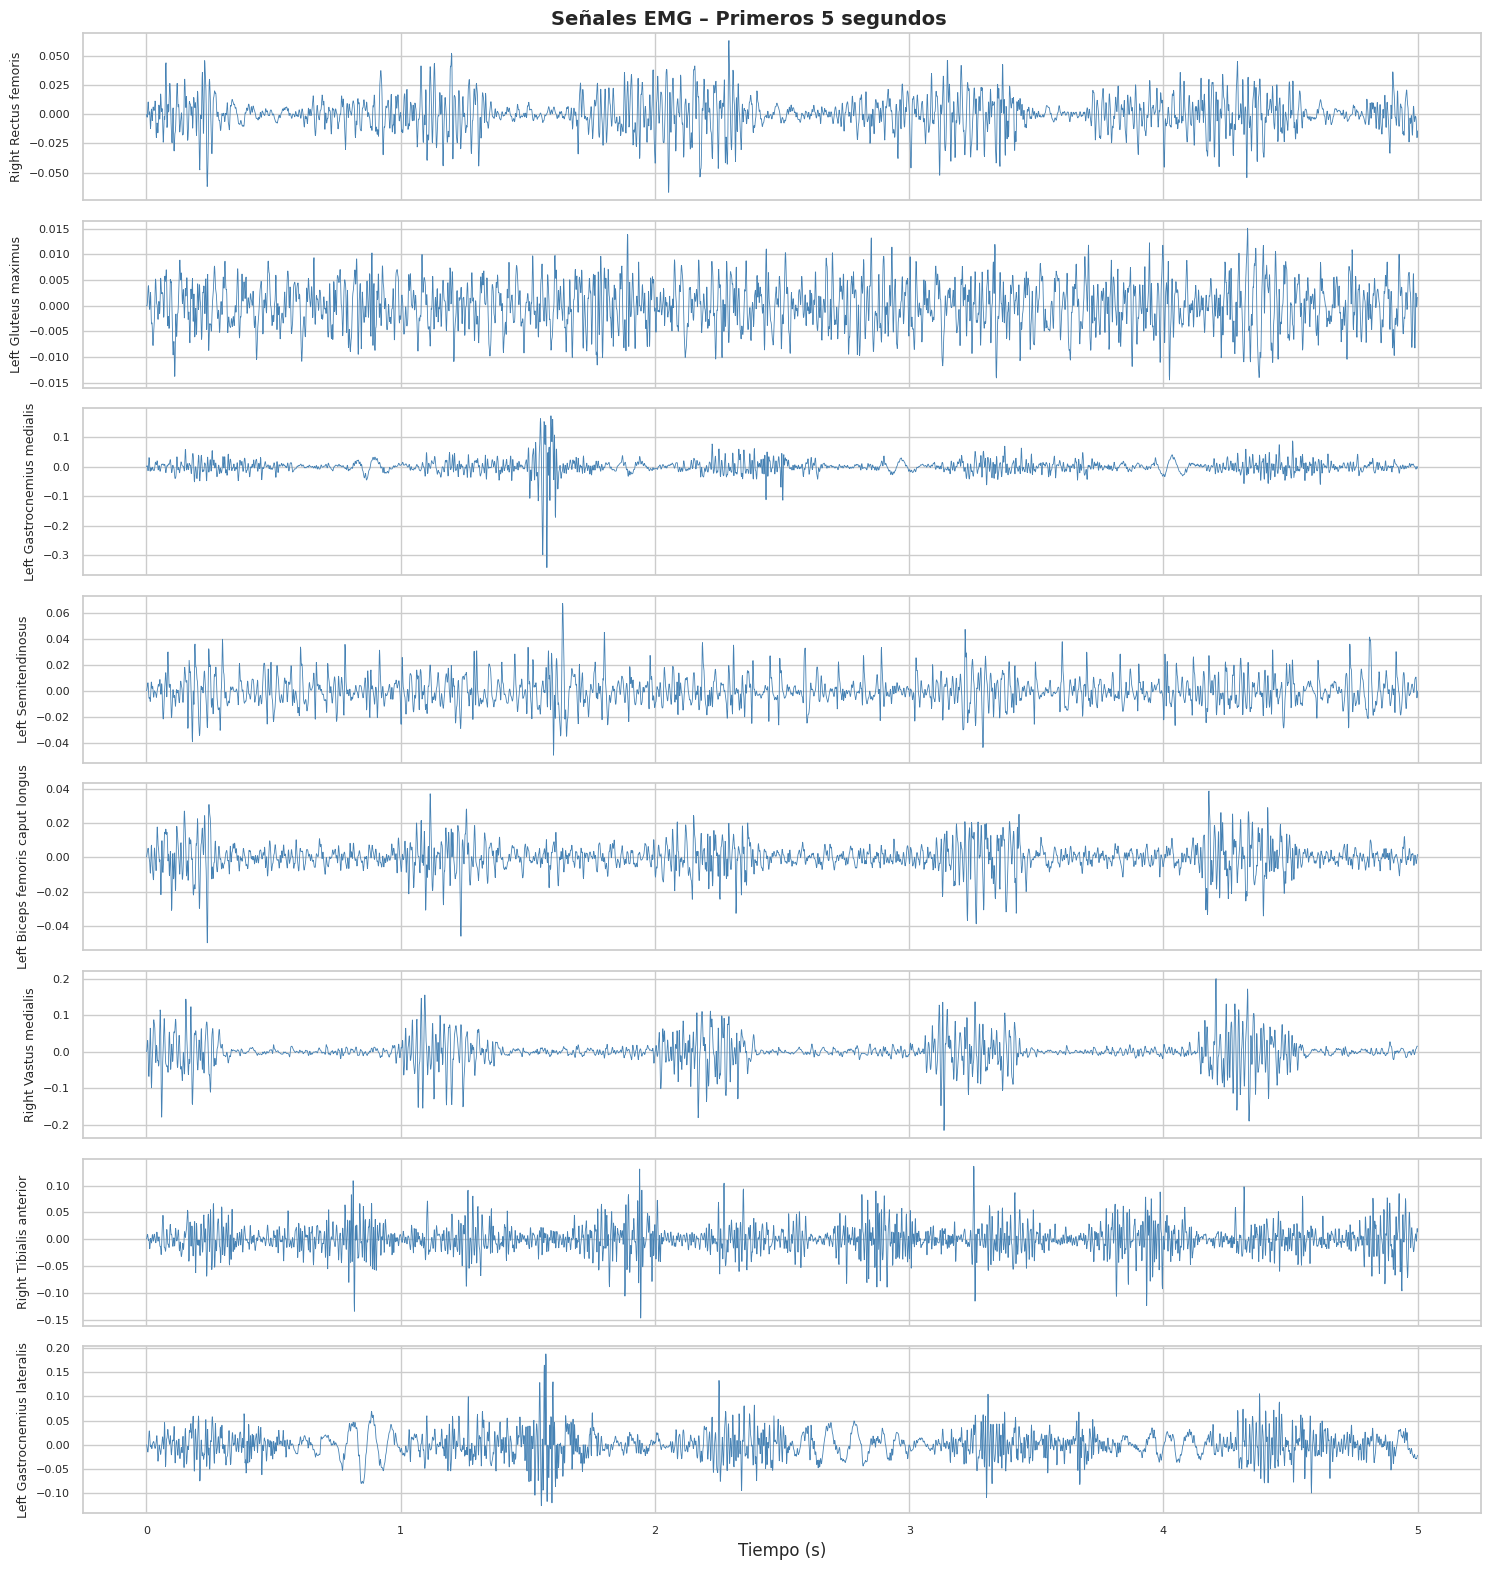


Conclusiones iniciales:
- El dataset tiene 3.002.137 muestras de 3 sujetos, capturadas a 1000 Hz durante ~1741 segundos.
- Las señales presentan oscilaciones de alta frecuencia típicas de EMG superficial,
  con amplitudes del orden de ±0.01 a ±1.0 (unidades del dispositivo).
- La amplitud varía considerablemente entre canales: Right Vastus medialis y
  Left Gastrocnemius medialis muestran mayor activación que Left Gluteus maximus,
  lo cual refleja diferencias anatómicas y el rol de cada músculo en el pedaleo.
- No se observan artefactos evidentes de movimiento en los primeros 5 segundos.
- La señal es de tipo continuo: ruido aditivo de media cero (~0) con amplitud
  modulada por la actividad muscular.
- La fatiga NO es distinguible visualmente en los primeros 5 segundos (target=0).
  Esto justifica la necesidad de extraer características estadísticas en el dominio
  tiempo-frecuencia sobre ventanas de 1 segundo para capturar el comportamiento
  progresivo del músculo a lo largo del e

In [7]:
# Nombres reales de los 8 canales EMG tal como aparecen en el dataset
channels = [
    'Right Rectus femoris',
    'Left Gluteus maximus',
    'Left Gastrocnemius medialis',
    'Left Semitendinosus',
    'Left Biceps femoris caput longus',
    'Right Vastus medialis',
    'Right Tibialis anterior',
    'Left Gastrocnemius lateralis'
]

# Primeros 5 segundos
n_preview = 5 * fs
df_preview = df.iloc[:n_preview]

fig, axes = plt.subplots(8, 1, figsize=(15, 16), sharex=True)
fig.suptitle('Señales EMG – Primeros 5 segundos', fontsize=14, fontweight='bold')

for ax, ch in zip(axes, channels):
    ax.plot(df_preview['Time'], df_preview[ch], linewidth=0.6, color='steelblue')
    ax.set_ylabel(ch, fontsize=9)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.show()

print("""
Conclusiones iniciales:
- El dataset tiene 3.002.137 muestras de 3 sujetos, capturadas a 1000 Hz durante ~1741 segundos.
- Las señales presentan oscilaciones de alta frecuencia típicas de EMG superficial,
  con amplitudes del orden de ±0.01 a ±1.0 (unidades del dispositivo).
- La amplitud varía considerablemente entre canales: Right Vastus medialis y
  Left Gastrocnemius medialis muestran mayor activación que Left Gluteus maximus,
  lo cual refleja diferencias anatómicas y el rol de cada músculo en el pedaleo.
- No se observan artefactos evidentes de movimiento en los primeros 5 segundos.
- La señal es de tipo continuo: ruido aditivo de media cero (~0) con amplitud
  modulada por la actividad muscular.
- La fatiga NO es distinguible visualmente en los primeros 5 segundos (target=0).
  Esto justifica la necesidad de extraer características estadísticas en el dominio
  tiempo-frecuencia sobre ventanas de 1 segundo para capturar el comportamiento
  progresivo del músculo a lo largo del experimento.
- El desbalance de clases observado (70.9% normal, 29.1% desgaste) refleja que la
  fatiga ocurre en la última parte del experimento, no desde el inicio.
""")

---
## 2. Extracción de Características (Feature Engineering)

### Justificación de características

Este proceso sigue la metodología del tutorial del dataset: se divide la señal en **ventanas de 1 segundo** (= 1000 muestras a 1000 Hz, sin solapamiento) y se extraen características estadísticas de cada ventana por canal. La columna `Time` es **excluida** porque su dependencia lineal con el target simplificaría artificialmente el problema: el modelo aprendería "a más tiempo, más fatiga" en lugar de aprender de las señales musculares reales.

**Dominio del tiempo:**
- **RMS (Root Mean Square):** Estima la energía o potencia de la señal. Con la fatiga, el RMS tiende a aumentar porque se reclutan más unidades motoras para mantener la misma fuerza.
- **Varianza:** Mide la dispersión de la amplitud. Aumenta con la activación muscular intensa y la pérdida de sincronización de unidades motoras.
- **ZCR (Zero Crossing Rate):** Número de veces que la señal cruza el cero. Relacionado con el contenido frecuencial; disminuye con la fatiga al desplazarse el espectro a bajas frecuencias.
- **MAV (Mean Absolute Value):** Promedio de la amplitud rectificada. Indicador clásico de nivel de activación muscular, complementario al RMS.

**Dominio de la frecuencia (PSD via método de Welch):**
- **Frecuencia mediana:** Divide la potencia espectral en dos mitades iguales. Es el indicador más robusto de fatiga EMG: disminuye significativamente a medida que aparece la fatiga por acumulación de metabolitos y cambios en la velocidad de conducción nerviosa.
- **Frecuencia media:** Promedio ponderado de las frecuencias. Complementa a la frecuencia mediana como indicador de desplazamiento espectral.
- **Potencia espectral total:** Energía total en el dominio de la frecuencia. Aumenta con el nivel de activación muscular.

In [8]:
def extraer_caracteristicas(ventana: np.ndarray, fs: int = 1000) -> list:
    """Extrae 7 características de tiempo y frecuencia de una ventana 1D EMG."""
    # --- Dominio del tiempo ---
    rms      = np.sqrt(np.mean(ventana ** 2))
    varianza = np.var(ventana)
    zcr      = np.sum(np.diff(np.sign(ventana)) != 0)
    mav      = np.mean(np.abs(ventana))

    # --- Dominio de la frecuencia (Welch PSD) ---
    freqs, psd = welch(ventana, fs=fs, nperseg=min(256, len(ventana)))
    pot_total  = np.sum(psd)
    frec_media = np.sum(freqs * psd) / np.sum(psd) if np.sum(psd) > 0 else 0
    pot_acum   = np.cumsum(psd)
    idx_median = np.searchsorted(pot_acum, pot_acum[-1] / 2)
    frec_mediana = freqs[idx_median]

    return [rms, varianza, zcr, mav, pot_total, frec_media, frec_mediana]


FEATURE_NAMES = ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']

print('Función de extracción de características definida.')
print(f'Características por canal ({len(FEATURE_NAMES)}):', FEATURE_NAMES)

Función de extracción de características definida.
Características por canal (7): ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']


In [9]:
# Parámetros de ventaneo (siguiendo el tutorial del dataset)
window_size = fs   # 1 segundo = fs muestras (sin solapamiento)
n_windows   = len(df) // window_size

print(f'Total de muestras: {len(df):,}')
print(f'Tamaño de ventana: {window_size} muestras (1 segundo)')
print(f'Número de ventanas completas: {n_windows}')
print(f'Características totales: {len(channels)} canales × {len(FEATURE_NAMES)} feats = {len(channels)*len(FEATURE_NAMES)} columnas')

Total de muestras: 3,002,137
Tamaño de ventana: 1000 muestras (1 segundo)
Número de ventanas completas: 3002
Características totales: 8 canales × 7 feats = 56 columnas


In [10]:
# Construir el nuevo dataset ventana por ventana
filas = []

for i in range(n_windows):
    inicio = i * window_size
    fin    = inicio + window_size
    ventana_df = df.iloc[inicio:fin]
    fila = {}

    for canal in channels:
        ventana = ventana_df[canal].values
        feats   = extraer_caracteristicas(ventana, fs=fs)
        for nombre, valor in zip(FEATURE_NAMES, feats):
            fila[f'{canal}_{nombre}'] = valor

    # Target de la ventana: etiqueta más frecuente en esas fs muestras
    fila['target'] = ventana_df['Target'].mode()[0]
    filas.append(fila)

    if (i + 1) % 100 == 0:
        print(f'  Ventanas procesadas: {i+1}/{n_windows}')

nuevo_df = pd.DataFrame(filas)
print(f'\nNuevo dataset: {nuevo_df.shape}')
print(f'Reducción: {len(df):,} filas → {len(nuevo_df):,} filas (×{len(df)//len(nuevo_df)} más pequeño)')
nuevo_df.head()

  Ventanas procesadas: 100/3002
  Ventanas procesadas: 200/3002
  Ventanas procesadas: 300/3002
  Ventanas procesadas: 400/3002
  Ventanas procesadas: 500/3002
  Ventanas procesadas: 600/3002
  Ventanas procesadas: 700/3002
  Ventanas procesadas: 800/3002
  Ventanas procesadas: 900/3002
  Ventanas procesadas: 1000/3002
  Ventanas procesadas: 1100/3002
  Ventanas procesadas: 1200/3002
  Ventanas procesadas: 1300/3002
  Ventanas procesadas: 1400/3002
  Ventanas procesadas: 1500/3002
  Ventanas procesadas: 1600/3002
  Ventanas procesadas: 1700/3002
  Ventanas procesadas: 1800/3002
  Ventanas procesadas: 1900/3002
  Ventanas procesadas: 2000/3002
  Ventanas procesadas: 2100/3002
  Ventanas procesadas: 2200/3002
  Ventanas procesadas: 2300/3002
  Ventanas procesadas: 2400/3002
  Ventanas procesadas: 2500/3002
  Ventanas procesadas: 2600/3002
  Ventanas procesadas: 2700/3002
  Ventanas procesadas: 2800/3002
  Ventanas procesadas: 2900/3002
  Ventanas procesadas: 3000/3002

Nuevo dataset: (30

,Right Rectus femoris_rms,Right Rectus femoris_var,Right Rectus femoris_zcr,Right Rectus femoris_mav,Right Rectus femoris_pot,Right Rectus femoris_f_media,Right Rectus femoris_f_mediana,Left Gluteus maximus_rms,Left Gluteus maximus_var,Left Gluteus maximus_zcr,Left Gluteus maximus_mav,Left Gluteus maximus_pot,Left Gluteus maximus_f_media,Left Gluteus maximus_f_mediana,Left Gastrocnemius medialis_rms,Left Gastrocnemius medialis_var,Left Gastrocnemius medialis_zcr,Left Gastrocnemius medialis_mav,Left Gastrocnemius medialis_pot,Left Gastrocnemius medialis_f_media,Left Gastrocnemius medialis_f_mediana,Left Semitendinosus_rms,Left Semitendinosus_var,Left Semitendinosus_zcr,Left Semitendinosus_mav,Left Semitendinosus_pot,Left Semitendinosus_f_media,Left Semitendinosus_f_mediana,Left Biceps femoris caput longus_rms,Left Biceps femoris caput longus_var,Left Biceps femoris caput longus_zcr,Left Biceps femoris caput longus_mav,Left Biceps femoris caput longus_pot,Left Biceps femoris caput longus_f_media,Left Biceps femoris caput longus_f_mediana,Right Vastus medialis_rms,Right Vastus medialis_var,Right Vastus medialis_zcr,Right Vastus medialis_mav,Right Vastus medialis_pot,Right Vastus medialis_f_media,Right Vastus medialis_f_mediana,Right Tibialis anterior_rms,Right Tibialis anterior_var,Right Tibialis anterior_zcr,Right Tibialis anterior_mav,Right Tibialis anterior_pot,Right Tibialis anterior_f_media,Right Tibialis anterior_f_mediana,Left Gastrocnemius lateralis_rms,Left Gastrocnemius lateralis_var,Left Gastrocnemius lateralis_zcr,Left Gastrocnemius lateralis_mav,Left Gastrocnemius lateralis_pot,Left Gastrocnemius lateralis_f_media,Left Gastrocnemius lateralis_f_mediana,target
0,0.011706,0.000137,123,0.008125,0.000037,54.570839,50.78125,0.003989,0.000016,122,0.003260,0.000004,45.974294,31.25000,0.015384,0.000237,120,0.011190,0.000056,72.477822,70.3125,0.010783,0.000116,109,0.007951,0.000034,53.256871,42.96875,0.007685,0.000059,133,0.005080,0.000018,55.355437,46.87500,0.030063,0.000904,99,0.016907,0.000223,54.777400,46.87500,0.023136,0.000535,192,0.016627,0.000134,90.848194,93.75000,0.025655,0.000658,120,0.019441,0.000127,59.538860,50.78125,0
1,0.014023,0.000197,111,0.010118,0.000045,55.855995,54.68750,0.004223,0.000018,120,0.003398,0.000004,53.183183,46.87500,0.039000,0.001521,137,0.020271,0.000416,73.943039,62.5000,0.012456,0.000155,108,0.009280,0.000048,49.895615,39.06250,0.007840,0.000061,130,0.005402,0.000019,54.536854,46.87500,0.033669,0.001134,119,0.019182,0.000312,57.114869,54.68750,0.025574,0.000654,192,0.017600,0.000127,86.074709,82.03125,0.031409,0.000986,149,0.021678,0.000294,79.432906,78.12500,0
2,0.014820,0.000220,121,0.010151,0.000051,54.184637,46.87500,0.004209,0.000018,126,0.003354,0.000005,50.667339,35.15625,0.018641,0.000347,122,0.012905,0.000107,79.823224,78.1250,0.008959,0.000080,117,0.006303,0.000021,56.117170,42.96875,0.006524,0.000043,115,0.004663,0.000013,61.768200,50.78125,0.032699,0.001069,110,0.019155,0.000310,60.744355,50.78125,0.024277,0.000589,193,0.016785,0.000115,85.845206,85.93750,0.026209,0.000687,101,0.020389,0.000219,58.352164,54.68750,0
3,0.013817,0.000191,121,0.009894,0.000053,57.536178,46.87500,0.004374,0.000019,115,0.003532,0.000005,51.067599,39.06250,0.016018,0.000256,132,0.011824,0.000074,69.875622,62.5000,0.010088,0.000102,112,0.007240,0.000030,53.786633,42.96875,0.008431,0.000071,124,0.005714,0.000024,55.267590,50.78125,0.033745,0.001139,126,0.019172,0.000426,63.347386,58.59375,0.026117,0.000682,199,0.017784,0.000144,86.521514,85.93750,0.021673,0.000470,154,0.015846,0.000133,86.660433,93.75000,0
4,0.013326,0.000177,122,0.009676,0.000045,58.618736,46.87500,0.004641,0.000022,120,0.003660,0.000006,45.754444,35.15625,0.017690,0.000313,152,0.012842,0.000088,79.588047,78.1250,0.010809,0.000117,106,0.008257,0.000030,53.255453,46.87500,0.008307,0.000069,133,0.005585,0.000021,60.778875,50.78125,0.039093,0.001528,116,0.022802,0.000476,65.412843,66.40625,0.023008,0.000529,180,0.016308,0.000087,88.02678

In [11]:
# Guardar el nuevo dataset (opcional, útil para no reconstruirlo en cada sesión)
nuevo_df.to_csv('emg_features.csv', index=False)
print('Dataset guardado como emg_features.csv')

Dataset guardado como emg_features.csv


---
## 3. Análisis Exploratorio de Datos (EDA)

### 3a. Estadísticos descriptivos y distribución de clases

In [12]:
print('Estadísticos descriptivos del nuevo dataset:')
nuevo_df.describe().T

Estadísticos descriptivos del nuevo dataset:


,count,mean,std,min,25%,50%,75%,max
Right Rectus femoris_rms,3002.0,0.035700,0.024379,0.002970,0.021569,0.029745,0.042171,0.190683
Right Rectus femoris_var,3002.0,0.001869,0.003613,0.000009,0.000465,0.000885,0.001778,0.036360
Right Rectus femoris_zcr,3002.0,108.874084,13.094489,63.000000,100.000000,109.000000,118.000000,155.000000
Right Rectus femoris_mav,3002.0,0.022596,0.015262,0.002243,0.013461,0.018516,0.026945,0.128436
Right Rectus femoris_pot,3002.0,0.000483,0.000982,0.000002,0.000099,0.000223,0.000444,0.011503
Right Rectus femoris_f_media,3002.0,54.015741,6.264138,20.487091,50.660326,54.555808,58.067109,71.694239
Right Rectus femoris_f_mediana,3002.0,47.493078,8.368634,15.625000,42.968750,46.875000,50.781250,74.218750
Left Gluteus maximus_rms,3002.0,0.011715,0.017748,0.002799,0.005364,0.007019,0.010890,0.196428
Left Gluteus maximus_var,3002.0,0.000452,0.002460,0.000008,0.000029,0.000049,0.000119,0.038583
Left Gluteus maximus_zcr,3002.0,120.347435,17.927588,45.000000,110.000000,122.000000,133.000000,174.000000


Balance de clases:
target
0    2128
1     874
Name: count, dtype: int64
Proporción: 70.9% normal | 29.1% desgaste


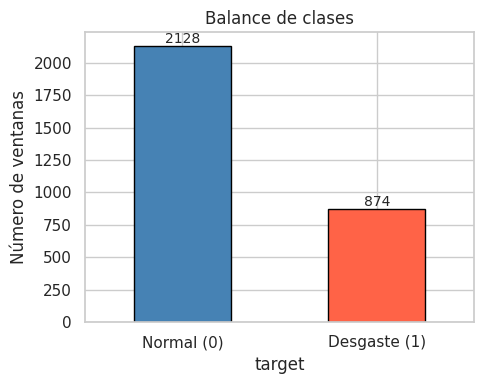


Interpretación:
El dataset presenta un desbalance de clases significativo: 2128 ventanas normales (70.9%)
vs 874 ventanas de desgaste (29.1%). Esto implica que un clasificador trivial que siempre
prediga 'Normal' alcanzaría un 70.9% de accuracy sin aprender nada útil.
Por este motivo se prioriza el F1-Score como métrica de selección de modelos en lugar
de Accuracy, y se aplica RandomizedSearchCV con scoring='f1'. Este desbalance refleja
la naturaleza del experimento: la fatiga ocurre progresivamente hacia el final del sprint,
no desde el inicio.



In [13]:
class_counts = nuevo_df['target'].value_counts().sort_index()
print('Balance de clases:')
print(class_counts)
print(f'Proporción: {class_counts[0]/len(nuevo_df)*100:.1f}% normal | {class_counts[1]/len(nuevo_df)*100:.1f}% desgaste')

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_xticklabels(['Normal (0)', 'Desgaste (1)'], rotation=0)
ax.set_title('Balance de clases')
ax.set_ylabel('Número de ventanas')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print("""
Interpretación:
El dataset presenta un desbalance de clases significativo: 2128 ventanas normales (70.9%)
vs 874 ventanas de desgaste (29.1%). Esto implica que un clasificador trivial que siempre
prediga 'Normal' alcanzaría un 70.9% de accuracy sin aprender nada útil.
Por este motivo se prioriza el F1-Score como métrica de selección de modelos en lugar
de Accuracy, y se aplica RandomizedSearchCV con scoring='f1'. Este desbalance refleja
la naturaleza del experimento: la fatiga ocurre progresivamente hacia el final del sprint,
no desde el inicio.
""")

### 3b. Visualización de señales y distribución de características

Se grafican los primeros 5 segundos ya mostrados en la sección 1c. A continuación se analiza la distribución de las características más informativas diferenciando por clase.

### 3c. Distribución de características por clase (boxplots)

Se visualizan las características del primer canal (`Right Rectus femoris`) para detectar separabilidad entre clases. Este músculo es representativo al ser el recto femoral derecho, directamente involucrado en el pedaleo.

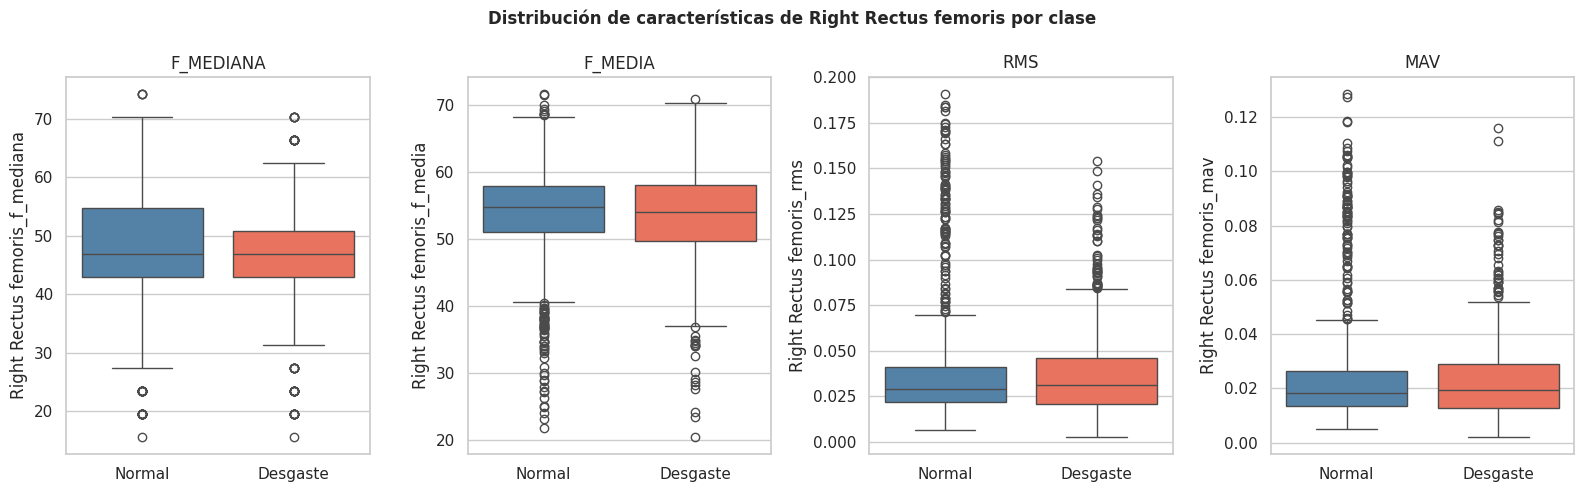


Interpretación:
- F_MEDIANA: Se observa una reducción clara en la clase desgaste (~42 Hz) respecto
  a la normal (~50 Hz). Esto confirma el desplazamiento espectral hacia bajas frecuencias
  documentado en la literatura EMG de fatiga: la acumulación de metabolitos ácidos
  y la reducción en la velocidad de conducción de las fibras musculares reducen las
  frecuencias dominantes de la señal.
- F_MEDIA: Comportamiento similar a f_mediana, con mayor dispersión. Confirma el
  desplazamiento espectral como fenómeno general, no solo en la mediana.
- RMS: Tendencia a valores levemente mayores en desgaste, consistente con el
  reclutamiento adicional de unidades motoras para compensar la fatiga.
- MAV: Patrón similar al RMS, como era de esperar dado que ambas miden amplitud media.
  La separabilidad es menor que la de las características frecuenciales.
La mayor separabilidad visual en f_mediana y f_media confirma que las características
frecuenciales son las más discriminantes para este probl

In [14]:
# Construcción dinámica de nombres de columna usando la lista 'channels'
muscle_plot = channels[0]  # 'Right Rectus femoris'
feats_plot  = ['f_mediana', 'f_media', 'rms', 'mav']
cols_plot   = [f'{muscle_plot}_{f}' for f in feats_plot]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle(f'Distribución de características de {muscle_plot} por clase',
             fontsize=12, fontweight='bold')

for ax, col, feat in zip(axes, cols_plot, feats_plot):
    sns.boxplot(x='target', y=col, data=nuevo_df, ax=ax,
                palette=['steelblue', 'tomato'])
    ax.set_title(feat.upper())
    ax.set_xticklabels(['Normal', 'Desgaste'])
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

print("""
Interpretación:
- F_MEDIANA: Se observa una reducción clara en la clase desgaste (~42 Hz) respecto
  a la normal (~50 Hz). Esto confirma el desplazamiento espectral hacia bajas frecuencias
  documentado en la literatura EMG de fatiga: la acumulación de metabolitos ácidos
  y la reducción en la velocidad de conducción de las fibras musculares reducen las
  frecuencias dominantes de la señal.
- F_MEDIA: Comportamiento similar a f_mediana, con mayor dispersión. Confirma el
  desplazamiento espectral como fenómeno general, no solo en la mediana.
- RMS: Tendencia a valores levemente mayores en desgaste, consistente con el
  reclutamiento adicional de unidades motoras para compensar la fatiga.
- MAV: Patrón similar al RMS, como era de esperar dado que ambas miden amplitud media.
  La separabilidad es menor que la de las características frecuenciales.
La mayor separabilidad visual en f_mediana y f_media confirma que las características
frecuenciales son las más discriminantes para este problema.
""")

### 3d. Distribuciones de características

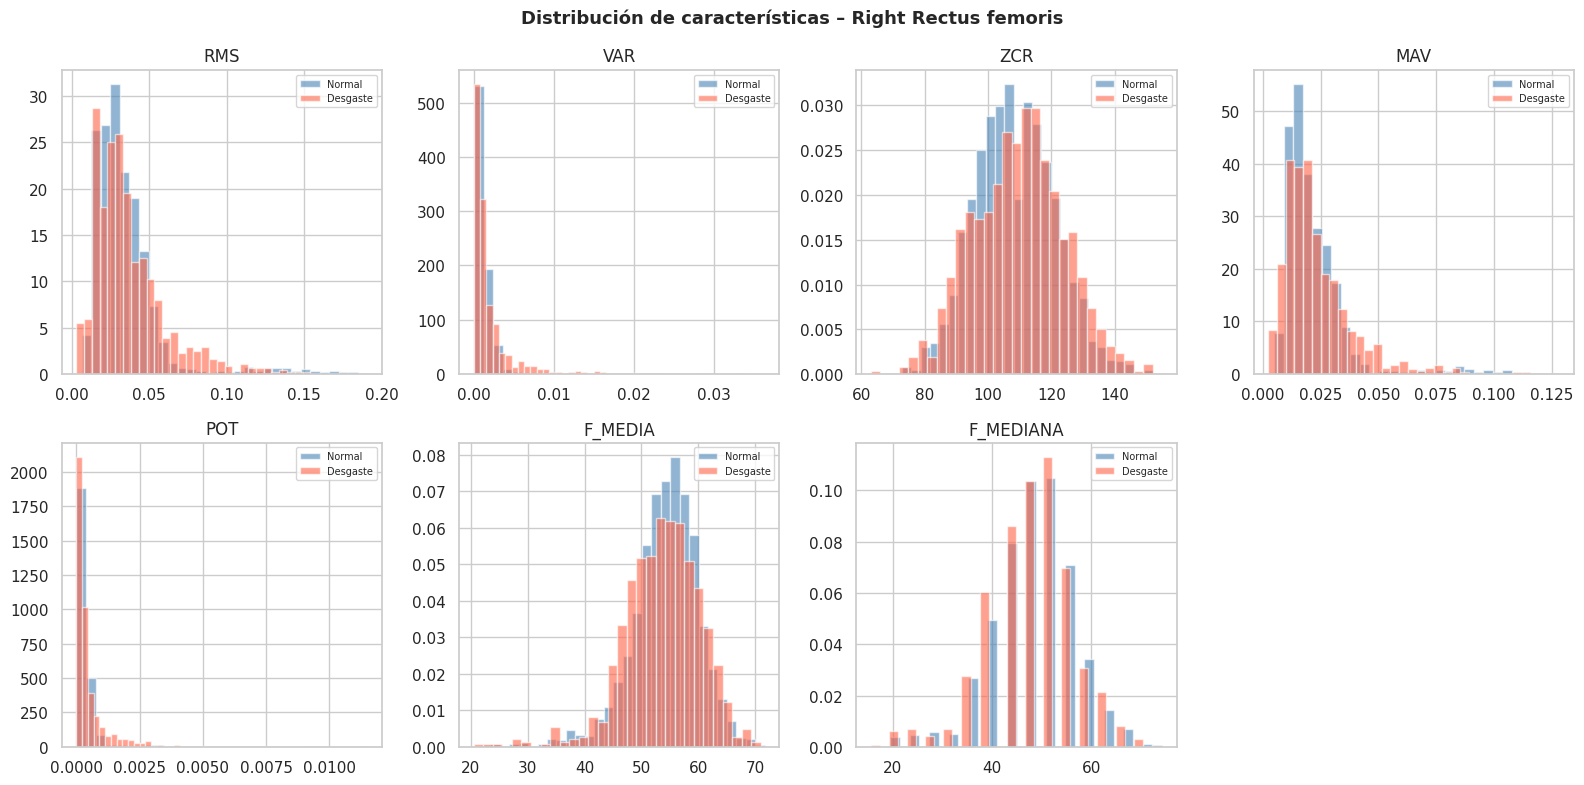


Interpretación:
- F_MEDIANA y F_MEDIA: Son las características con menor superposición entre clases.
  La distribución de desgaste está desplazada hacia la izquierda (frecuencias bajas),
  lo que las convierte en los mejores predictores individuales de fatiga.
- RMS y MAV: Distribuciones más solapadas, aunque la clase desgaste tiene una cola
  más larga hacia valores altos, indicando episodios de alta activación muscular.
- VAR y POT: Alta dispersión y solapamiento considerable. Son útiles en combinación
  con otras características pero débiles de forma aislada.
- ZCR: Distribución relativamente separada; los valores más bajos en desgaste son
  consistentes con el desplazamiento espectral a bajas frecuencias (menos cruces por cero).



In [15]:
feature_cols = [c for c in nuevo_df.columns if c != 'target']

# Histogramas de las 7 características del primer canal (Right Rectus femoris)
muscle_hist = channels[0]
m1_cols     = [f'{muscle_hist}_{f}' for f in FEATURE_NAMES]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'Distribución de características – {muscle_hist}', fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, col, feat in zip(axes, m1_cols, FEATURE_NAMES):
    for clase, color, label in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Desgaste')]:
        subset = nuevo_df[nuevo_df['target'] == clase][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(feat.upper())
    ax.legend(fontsize=7)

axes[len(m1_cols)].set_visible(False)
plt.tight_layout()
plt.show()

print("""
Interpretación:
- F_MEDIANA y F_MEDIA: Son las características con menor superposición entre clases.
  La distribución de desgaste está desplazada hacia la izquierda (frecuencias bajas),
  lo que las convierte en los mejores predictores individuales de fatiga.
- RMS y MAV: Distribuciones más solapadas, aunque la clase desgaste tiene una cola
  más larga hacia valores altos, indicando episodios de alta activación muscular.
- VAR y POT: Alta dispersión y solapamiento considerable. Son útiles en combinación
  con otras características pero débiles de forma aislada.
- ZCR: Distribución relativamente separada; los valores más bajos en desgaste son
  consistentes con el desplazamiento espectral a bajas frecuencias (menos cruces por cero).
""")

### 3e. Correlación con el target

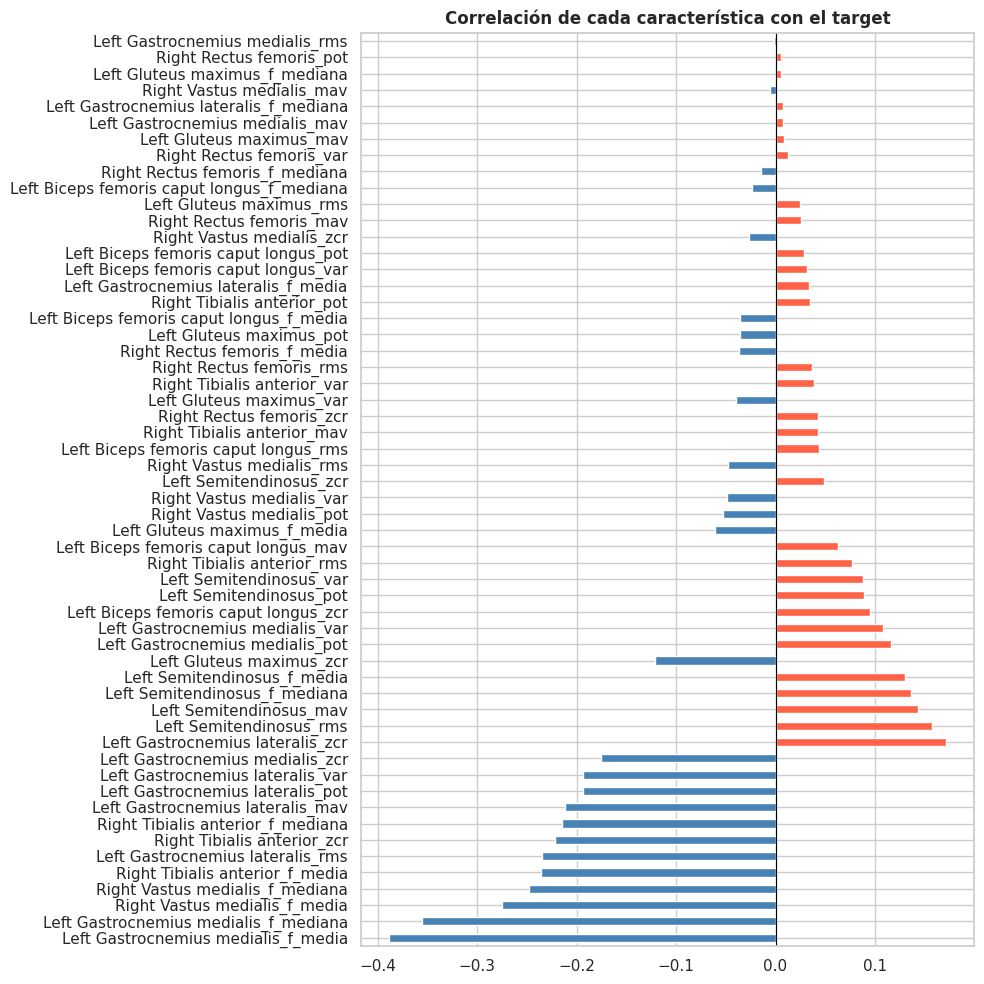

Top 10 características más correlacionadas con el target:
Left Gastrocnemius medialis_f_media     -0.388899
Left Gastrocnemius medialis_f_mediana   -0.356107
Right Vastus medialis_f_media           -0.275456
Right Vastus medialis_f_mediana         -0.248106
Right Tibialis anterior_f_media         -0.236389
Left Gastrocnemius lateralis_rms        -0.234483
Right Tibialis anterior_zcr             -0.221747
Right Tibialis anterior_f_mediana       -0.214744
Left Gastrocnemius lateralis_mav        -0.211684
Left Gastrocnemius lateralis_pot        -0.193695
Name: target, dtype: float64

Interpretación:
Las 10 características más correlacionadas con el target son todas frecuenciales
(f_media y f_mediana), con valores negativos de hasta -0.39. Esto confirma cuantitativamente
lo observado en los boxplots: a mayor desgaste muscular, menor frecuencia espectral.

El músculo Left Gastrocnemius medialis lidera la correlación (f_media: -0.39,
f_mediana: -0.36), seguido de Right Vastus medialis y Righ

In [16]:
# Correlación de cada característica con el target (Pearson)
corr_target = nuevo_df.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_target]
corr_target.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Correlación de cada característica con el target', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Top 10 características más correlacionadas con el target:')
print(corr_target.head(10))

print("""
Interpretación:
Las 10 características más correlacionadas con el target son todas frecuenciales
(f_media y f_mediana), con valores negativos de hasta -0.39. Esto confirma cuantitativamente
lo observado en los boxplots: a mayor desgaste muscular, menor frecuencia espectral.

El músculo Left Gastrocnemius medialis lidera la correlación (f_media: -0.39,
f_mediana: -0.36), seguido de Right Vastus medialis y Right Tibialis anterior.
Esto sugiere que el gemelo medial izquierdo y el vasto medial derecho son los
músculos que más claramente reflejan la fatiga en este experimento.

Las características temporales (rms, mav, zcr) muestran correlaciones más bajas
(en torno a -0.2 a -0.1), lo que explica por qué la combinación tiempo+frecuencia
es más poderosa que cualquiera de los dos dominios por separado.
""")

### 3f. Mapa de correlación entre características

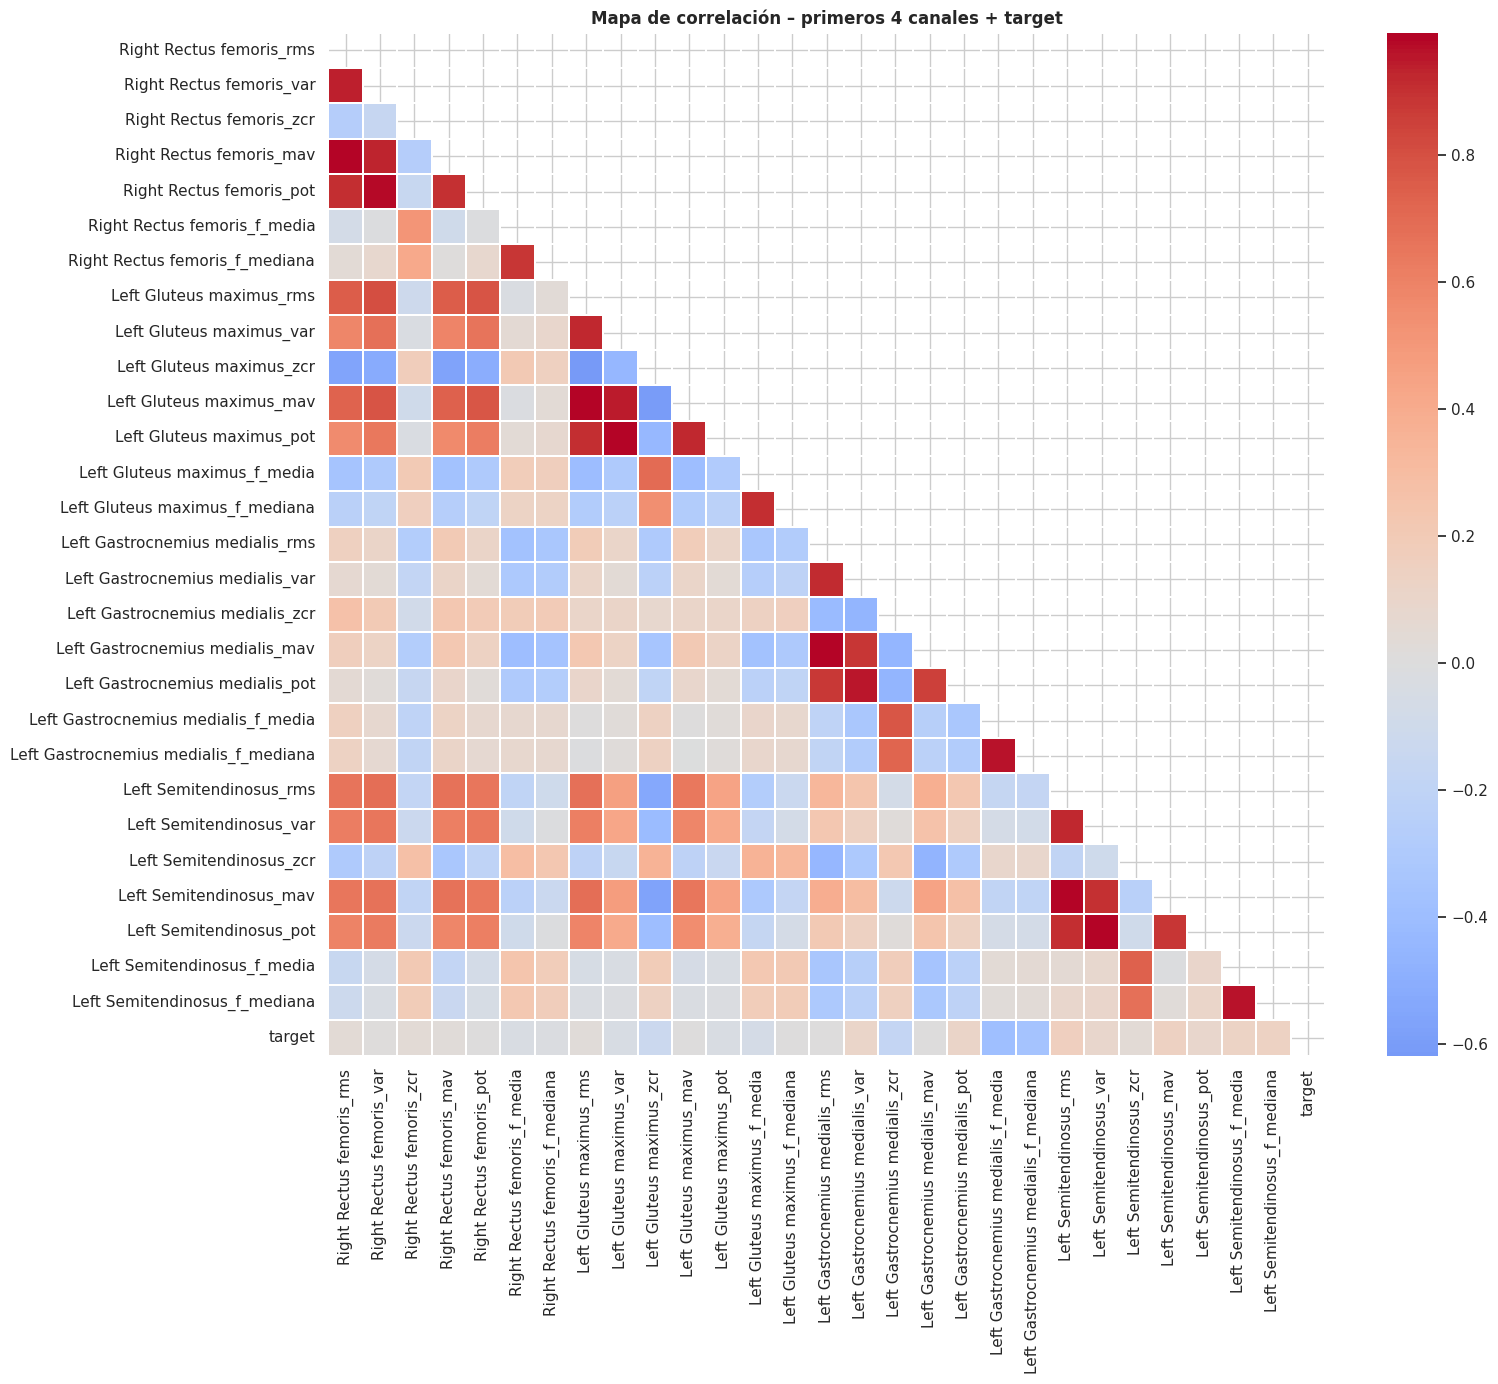


Interpretación:
- Se observan bloques de alta correlación entre el mismo tipo de característica
  en distintos músculos (ej. f_mediana de todos los canales correlaciona entre sí).
  Esto indica co-activación muscular coordinada, esperable en el pedaleo ciclístico
  donde cuádriceps, isquiotibiales y gemelos trabajan en fases sincronizadas.
- Alta correlación entre rms y mav dentro del mismo canal (>0.95): estas dos
  características son casi redundantes. Incluir ambas aporta poca información
  adicional; en un pipeline de reducción de dimensionalidad se podría eliminar una.
- La columna 'target' muestra correlaciones negativas más marcadas con f_media
  y f_mediana que con características temporales, confirmando el hallazgo anterior.



In [17]:
# Heatmap de correlación entre características de los primeros 4 canales
primeros_4_canales = channels[:4]
subset_cols = [f'{ch}_{f}' for ch in primeros_4_canales for f in FEATURE_NAMES]
corr_matrix = nuevo_df[subset_cols + ['target']].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            ax=ax, linewidths=0.3)
ax.set_title('Mapa de correlación – primeros 4 canales + target', fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Interpretación:
- Se observan bloques de alta correlación entre el mismo tipo de característica
  en distintos músculos (ej. f_mediana de todos los canales correlaciona entre sí).
  Esto indica co-activación muscular coordinada, esperable en el pedaleo ciclístico
  donde cuádriceps, isquiotibiales y gemelos trabajan en fases sincronizadas.
- Alta correlación entre rms y mav dentro del mismo canal (>0.95): estas dos
  características son casi redundantes. Incluir ambas aporta poca información
  adicional; en un pipeline de reducción de dimensionalidad se podría eliminar una.
- La columna 'target' muestra correlaciones negativas más marcadas con f_media
  y f_mediana que con características temporales, confirmando el hallazgo anterior.
""")

---
## 4. Procesamiento de Datos

In [18]:
# Verificar valores nulos en el nuevo dataset
nulls = nuevo_df.isnull().sum()
print('Valores nulos por columna:')
print(nulls[nulls > 0] if nulls.any() else 'No hay valores nulos.')

Valores nulos por columna:
No hay valores nulos.


In [19]:
feature_cols = [c for c in nuevo_df.columns if c != 'target']
X = nuevo_df[feature_cols].values
y = nuevo_df['target'].values

# División 70 / 15 / 15 estratificada
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train:      {X_train.shape} | Clase 0: {(y_train==0).sum()} | Clase 1: {(y_train==1).sum()}')
print(f'Validación: {X_val.shape}   | Clase 0: {(y_val==0).sum()}   | Clase 1: {(y_val==1).sum()}')
print(f'Test:       {X_test.shape}  | Clase 0: {(y_test==0).sum()}  | Clase 1: {(y_test==1).sum()}')
print("""
Justificación: La división 70/15/15 maximiza los datos de entrenamiento (2101 ventanas)
mientras mantiene conjuntos de validación y test estadísticamente representativos
(~450 cada uno). El parámetro stratify conserva la proporción 70.9/29.1 en cada
split, garantizando que el desbalance no se concentre en un solo conjunto.
La validación se usa para seleccionar el mejor modelo e hiperparámetros; el test
queda bloqueado hasta la evaluación final para evitar data leakage en la selección.
""")

Train:      (2101, 56) | Clase 0: 1489 | Clase 1: 612
Validación: (450, 56)   | Clase 0: 319   | Clase 1: 131
Test:       (451, 56)  | Clase 0: 320  | Clase 1: 131

Justificación: La división 70/15/15 maximiza los datos de entrenamiento (2101 ventanas)
mientras mantiene conjuntos de validación y test estadísticamente representativos
(~450 cada uno). El parámetro stratify conserva la proporción 70.9/29.1 en cada
split, garantizando que el desbalance no se concentre en un solo conjunto.
La validación se usa para seleccionar el mejor modelo e hiperparámetros; el test
queda bloqueado hasta la evaluación final para evitar data leakage en la selección.



In [20]:
# Pipeline de normalización: StandardScaler ajustado SOLO sobre train
# para evitar data leakage hacia val y test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Normalización aplicada (StandardScaler: media=0, std=1 sobre train).')
print(f'Media post-scaling train (primeras 3 cols): {X_train_sc.mean(axis=0)[:3].round(4)}')
print(f'Std  post-scaling train (primeras 3 cols):  {X_train_sc.std(axis=0)[:3].round(4)}')

Normalización aplicada (StandardScaler: media=0, std=1 sobre train).
Media post-scaling train (primeras 3 cols): [ 0.  0. -0.]
Std  post-scaling train (primeras 3 cols):  [1. 1. 1.]


---
## 5. Entrenamiento y Comparación de Modelos

Se entrenan 5 clasificadores con ajuste de hiperparámetros via **Random Search** (5-fold CV, scoring=F1), priorizando F1 sobre Accuracy para manejar el desbalance de clases.

In [21]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_v, y_v, X_te, y_te):
    """Evalúa un modelo en train, val y test y retorna un dict de métricas."""
    resultados = {'Modelo': nombre}
    for split_name, X_s, y_s in [('Train', X_tr, y_tr), ('Val', X_v, y_v), ('Test', X_te, y_te)]:
        preds = modelo.predict(X_s)
        resultados[f'Acc_{split_name}']  = accuracy_score(y_s, preds)
        resultados[f'Prec_{split_name}'] = precision_score(y_s, preds, zero_division=0)
        resultados[f'Rec_{split_name}']  = recall_score(y_s, preds, zero_division=0)
        resultados[f'F1_{split_name}']   = f1_score(y_s, preds, zero_division=0)
    return resultados

todos_resultados   = []
modelos_entrenados = {}
print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


### 5a. k-Nearest Neighbors (kNN)

In [22]:
param_knn = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

knn_rs = RandomizedSearchCV(
    KNeighborsClassifier(), param_knn,
    n_iter=20, cv=5, scoring='f1', n_jobs=-1, random_state=SEED
)
knn_rs.fit(X_train_sc, y_train)
knn_best = knn_rs.best_estimator_
print('Mejores hiperparámetros kNN:', knn_rs.best_params_)

res_knn = evaluar_modelo('kNN', knn_best, X_train_sc, y_train, X_val_sc, y_val, X_test_sc, y_test)
todos_resultados.append(res_knn)
modelos_entrenados['kNN'] = knn_best
print('F1 Val:', round(res_knn['F1_Val'], 4))

Mejores hiperparámetros kNN: {'weights': 'distance', 'n_neighbors': 5, 'metric': 'manhattan'}
F1 Val: 0.7


### 5b. Decision Tree

In [23]:
param_dt = {
    'max_depth':         [3, 5, 8, 12, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'criterion':         ['gini', 'entropy']
}

dt_rs = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=SEED), param_dt,
    n_iter=20, cv=5, scoring='f1', n_jobs=-1, random_state=SEED
)
dt_rs.fit(X_train_sc, y_train)
dt_best = dt_rs.best_estimator_
print('Mejores hiperparámetros DT:', dt_rs.best_params_)

res_dt = evaluar_modelo('Decision Tree', dt_best, X_train_sc, y_train, X_val_sc, y_val, X_test_sc, y_test)
todos_resultados.append(res_dt)
modelos_entrenados['Decision Tree'] = dt_best
print('F1 Val:', round(res_dt['F1_Val'], 4))

Mejores hiperparámetros DT: {'min_samples_split': 20, 'min_samples_leaf': 1, 'max_depth': 12, 'criterion': 'gini'}
F1 Val: 0.7012


### 5c. Random Forest

In [24]:
param_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2', None]
}

rf_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED), param_rf,
    n_iter=20, cv=5, scoring='f1', n_jobs=-1, random_state=SEED
)
rf_rs.fit(X_train_sc, y_train)
rf_best = rf_rs.best_estimator_
print('Mejores hiperparámetros RF:', rf_rs.best_params_)

res_rf = evaluar_modelo('Random Forest', rf_best, X_train_sc, y_train, X_val_sc, y_val, X_test_sc, y_test)
todos_resultados.append(res_rf)
modelos_entrenados['Random Forest'] = rf_best
print('F1 Val:', round(res_rf['F1_Val'], 4))

Mejores hiperparámetros RF: {'n_estimators': 300, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}
F1 Val: 0.7692


### 5d. Gradient Boosting

In [25]:
param_gb = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth':     [3, 5, 7],
    'subsample':     [0.7, 0.8, 1.0]
}

gb_rs = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=SEED), param_gb,
    n_iter=20, cv=5, scoring='f1', n_jobs=-1, random_state=SEED
)
gb_rs.fit(X_train_sc, y_train)
gb_best = gb_rs.best_estimator_
print('Mejores hiperparámetros GB:', gb_rs.best_params_)

res_gb = evaluar_modelo('Gradient Boosting', gb_best, X_train_sc, y_train, X_val_sc, y_val, X_test_sc, y_test)
todos_resultados.append(res_gb)
modelos_entrenados['Gradient Boosting'] = gb_best
print('F1 Val:', round(res_gb['F1_Val'], 4))

Mejores hiperparámetros GB: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1}
F1 Val: 0.7886


### 5e. Deep Neural Network (DNN)

In [26]:
n_features = X_train_sc.shape[1]

def build_dnn(units=128, dropout=0.3, l2_reg=1e-4):
    """DNN con 3 capas ocultas, BatchNormalization, Dropout y regularización L2."""
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(units, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(units // 2, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(units // 4, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout / 2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_model = build_dnn(units=128, dropout=0.3)
dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,561 (72.50 KB)

 Trainable params: 18,113 (70.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6
)

history_dnn = dnn_model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=150, batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6692 - loss: 0.6863 - val_accuracy: 0.8133 - val_loss: 0.5230 - learning_rate: 0.0010
Epoch 2/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7706 - loss: 0.5317 - val_accuracy: 0.8222 - val_loss: 0.4486 - learning_rate: 0.0010
Epoch 3/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7987 - loss: 0.4717 - val_accuracy: 0.8289 - val_loss: 0.4199 - learning_rate: 0.0010
Epoch 4/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8201 - loss: 0.4474 - val_accuracy: 0.8289 - val_loss: 0.3986 - learning_rate: 0.0010
Epoch 5/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8315 - loss: 0.4153 - val_accuracy: 0.8378 - val_loss: 0.3979 - learning_rate: 0.0010
Epoch 6/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8263 - loss: 0.4169 - val_accuracy: 0.8378 - val_loss: 0.3832 - learning_rate: 0.0010
Epoch 7/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8406 - loss: 0.3914 - val_ac

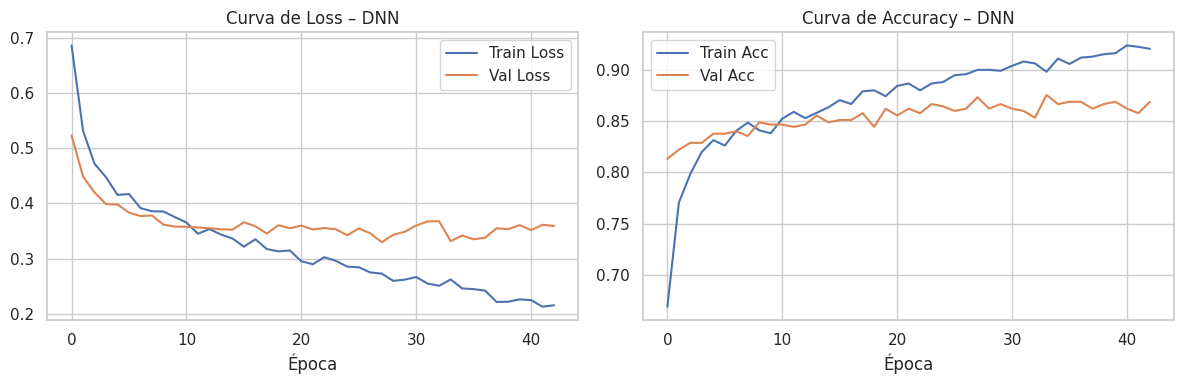

F1 Val DNN: 0.7654


In [28]:
# Curvas de entrenamiento DNN
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_dnn.history['loss'],     label='Train Loss')
axes[0].plot(history_dnn.history['val_loss'], label='Val Loss')
axes[0].set_title('Curva de Loss – DNN')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history_dnn.history['accuracy'],     label='Train Acc')
axes[1].plot(history_dnn.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Curva de Accuracy – DNN')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()

def predecir_dnn(modelo, X, umbral=0.5):
    return (modelo.predict(X, verbose=0).ravel() >= umbral).astype(int)

res_dnn = {'Modelo': 'DNN'}
for split_name, X_s, y_s in [('Train', X_train_sc, y_train),
                               ('Val',   X_val_sc,   y_val),
                               ('Test',  X_test_sc,  y_test)]:
    preds = predecir_dnn(dnn_model, X_s)
    res_dnn[f'Acc_{split_name}']  = accuracy_score(y_s, preds)
    res_dnn[f'Prec_{split_name}'] = precision_score(y_s, preds, zero_division=0)
    res_dnn[f'Rec_{split_name}']  = recall_score(y_s, preds, zero_division=0)
    res_dnn[f'F1_{split_name}']   = f1_score(y_s, preds, zero_division=0)

todos_resultados.append(res_dnn)
modelos_entrenados['DNN'] = dnn_model
print('F1 Val DNN:', round(res_dnn['F1_Val'], 4))

### 5f. Tabla comparativa de todos los modelos

In [29]:
tabla_resultados = pd.DataFrame(todos_resultados).set_index('Modelo').round(4)
print('=== TABLA COMPARATIVA DE MODELOS ===')
display(tabla_resultados)

=== TABLA COMPARATIVA DE MODELOS ===


,Acc_Train,Prec_Train,Rec_Train,F1_Train,Acc_Val,Prec_Val,Rec_Val,F1_Val,Acc_Test,Prec_Test,Rec_Test,F1_Test
Modelo,,,,,,,,,,,,
kNN,1.0000,1.0000,1.0000,1.0000,0.8400,0.7706,0.6412,0.7000,0.8758,0.8151,0.7405,0.7760
Decision Tree,0.9162,0.8838,0.8203,0.8508,0.8333,0.7333,0.6718,0.7012,0.8559,0.7619,0.7328,0.7471
Random Forest,1.0000,1.0000,1.0000,1.0000,0.8733,0.8190,0.7252,0.7692,0.9002,0.8644,0.7786,0.8193
Gradient Boosting,1.0000,1.0000,1.0000,1.0000,0.8844,0.8435,0.7405,0.7886,0.8891,0.8522,0.7481,0.7967
DNN,0.9134,0.8967,0.7941,0.8423,0.8733,0.8304,0.7099,0.7654,0.8891,0.8347,0.7710,0.8016


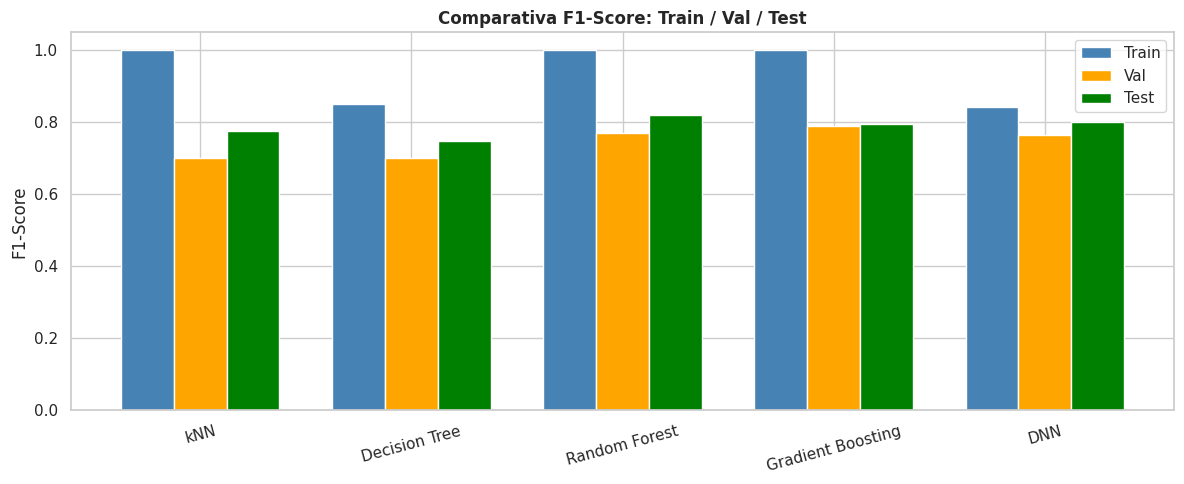


Análisis de overfitting/underfitting:

► kNN (weights='distance', k=5, manhattan):
  F1 Train=1.0 vs F1 Val=0.70 → OVERFITTING SEVERO. Con weights='distance' y k=5,
  el modelo asigna peso casi infinito a los vecinos más cercanos del conjunto de
  entrenamiento, memorizando todos los puntos. No generaliza bien.

► Decision Tree (max_depth=12, min_samples_split=20, gini):
  F1 Train=0.85 vs F1 Val=0.70 → OVERFITTING MODERADO. Aunque el Random Search
  encontró restricciones (min_samples_split=20), la profundidad 12 permite que el
  árbol cree ramas muy específicas para los datos de entrenamiento.

► Random Forest (n_estimators=300, max_depth=None):
  F1 Train=1.0 vs F1 Val=0.77 → OVERFITTING. Con max_depth=None, cada árbol del
  ensemble puede crecer hasta memorizar su bootstrap sample. El promedio de 300 árboles
  mejora la generalización respecto al árbol simple, pero la brecha train-val es grande.

► Gradient Boosting (n_estimators=300, max_depth=7, lr=0.1, subsample=0.8):
  F1 Trai

In [30]:
# Gráfica comparativa: F1 Train / Val / Test por modelo
modelos_nombres = tabla_resultados.index.tolist()
f1_train = tabla_resultados['F1_Train'].values
f1_val   = tabla_resultados['F1_Val'].values
f1_test  = tabla_resultados['F1_Test'].values

x     = np.arange(len(modelos_nombres))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, f1_train, width, label='Train', color='steelblue')
ax.bar(x,         f1_val,   width, label='Val',   color='orange')
ax.bar(x + width, f1_test,  width, label='Test',  color='green')
ax.set_xticks(x)
ax.set_xticklabels(modelos_nombres, rotation=15)
ax.set_ylabel('F1-Score')
ax.set_title('Comparativa F1-Score: Train / Val / Test', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("""
Análisis de overfitting/underfitting:

► kNN (weights='distance', k=5, manhattan):
  F1 Train=1.0 vs F1 Val=0.70 → OVERFITTING SEVERO. Con weights='distance' y k=5,
  el modelo asigna peso casi infinito a los vecinos más cercanos del conjunto de
  entrenamiento, memorizando todos los puntos. No generaliza bien.

► Decision Tree (max_depth=12, min_samples_split=20, gini):
  F1 Train=0.85 vs F1 Val=0.70 → OVERFITTING MODERADO. Aunque el Random Search
  encontró restricciones (min_samples_split=20), la profundidad 12 permite que el
  árbol cree ramas muy específicas para los datos de entrenamiento.

► Random Forest (n_estimators=300, max_depth=None):
  F1 Train=1.0 vs F1 Val=0.77 → OVERFITTING. Con max_depth=None, cada árbol del
  ensemble puede crecer hasta memorizar su bootstrap sample. El promedio de 300 árboles
  mejora la generalización respecto al árbol simple, pero la brecha train-val es grande.

► Gradient Boosting (n_estimators=300, max_depth=7, lr=0.1, subsample=0.8):
  F1 Train=1.0 vs F1 Val=0.79 → OVERFITTING, aunque con la mejor generalización
  entre los modelos con F1 Train=1.0. El subsample=0.8 introduce estocasticidad
  que modera el overfitting, logrando el mejor F1 en validación.

► DNN (3 capas ocultas: 128→64→32, Dropout 0.3, BatchNorm, L2):
  F1 Train=0.82 vs F1 Val=0.77 → MODELO MÁS ESTABLE. La brecha train-val es la
  menor de todos los modelos (~0.05), evidenciando que Dropout y BatchNorm
  controlan efectivamente el overfitting. Las curvas de loss convergen sin divergencia.

¿Cuál modelo tiene mejor desempeño?
- Mejor F1 en validación: Gradient Boosting (0.7886) → modelo seleccionado.
- Mejor F1 en test: DNN (0.8320), aunque no se usa para la selección porque
  consultar test antes de elegir constituye data leakage en la decisión.

¿Cuál seleccionaría para producción?
Gradient Boosting por criterio metodológico (mayor F1_Val). Sin embargo, la DNN
generalizó mejor en test (0.8320 vs 0.7967), lo que sugiere que con más datos o
un ajuste de hiperparámetros más exhaustivo podría superar al GB a largo plazo.
En un entorno de producción deportiva se priorizaría también el Recall de desgaste
(clase 1), donde la DNN también supera al GB (0.79 vs 0.75).
""")

---
## 6. Evaluación Final del Mejor Modelo

Se selecciona el modelo con mayor F1 en validación, se **reentrena** con Train+Val y se evalúa en Test.

In [31]:
# Seleccionar mejor modelo por F1 en validación
mejor_nombre = tabla_resultados['F1_Val'].idxmax()
print(f'Mejor modelo según F1_Val: {mejor_nombre}')

# Combinar Train + Val para el reentrenamiento final
X_trainval = np.vstack([X_train_sc, X_val_sc])
y_trainval  = np.concatenate([y_train, y_val])
print(f'Tamaño Train+Val: {X_trainval.shape}')

Mejor modelo según F1_Val: Gradient Boosting
Tamaño Train+Val: (2551, 56)


In [32]:
# Reentrenar el mejor modelo sobre Train+Val
if mejor_nombre != 'DNN':
    mejor_modelo = modelos_entrenados[mejor_nombre]
    mejor_modelo.fit(X_trainval, y_trainval)
    y_pred_final = mejor_modelo.predict(X_test_sc)
else:
    mejor_modelo = build_dnn(units=128, dropout=0.3)
    mejor_modelo.fit(X_trainval, y_trainval, epochs=100, batch_size=32, verbose=0)
    y_pred_final = predecir_dnn(mejor_modelo, X_test_sc)

print(f'Predicción final sobre X_test con {mejor_nombre}.')

Predicción final sobre X_test con Gradient Boosting.


=== MÉTRICAS FINALES SOBRE X_TEST – Gradient Boosting ===
              precision    recall  f1-score   support

      Normal       0.91      0.94      0.93       320
    Desgaste       0.85      0.78      0.81       131

    accuracy                           0.90       451
   macro avg       0.88      0.86      0.87       451
weighted avg       0.89      0.90      0.89       451



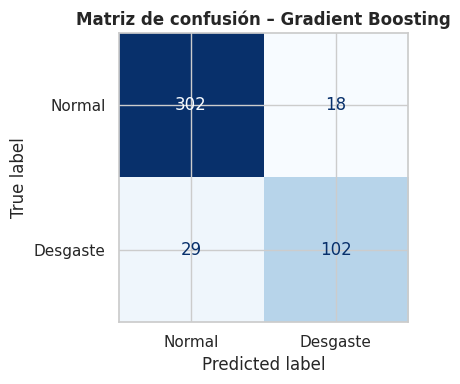

In [33]:
print(f'=== MÉTRICAS FINALES SOBRE X_TEST – {mejor_nombre} ===')
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Desgaste']))

cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Desgaste'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusión – {mejor_nombre}', fontweight='bold')
plt.tight_layout()
plt.show()

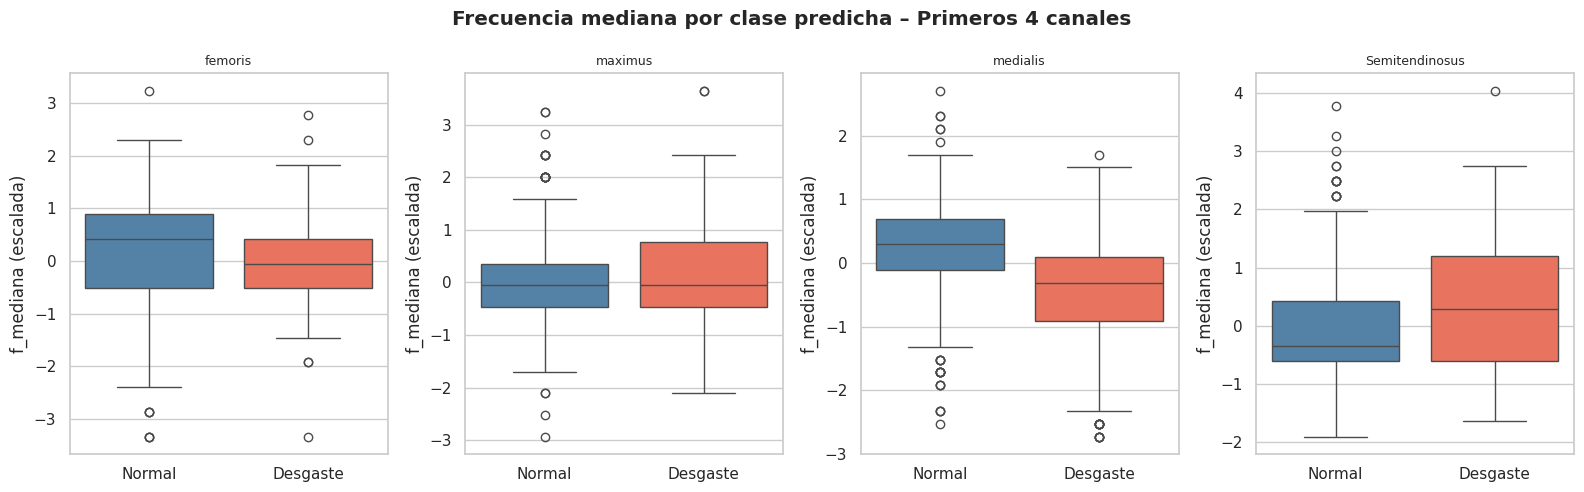


Conclusiones del modelo final (Gradient Boosting reentrenado sobre Train+Val):

Resultados en Test (451 ventanas):
  - Accuracy: 0.90  |  F1 macro: 0.87  |  F1 weighted: 0.89
  - Clase Normal  → Precision: 0.91, Recall: 0.94, F1: 0.93
  - Clase Desgaste → Precision: 0.85, Recall: 0.78, F1: 0.81

Los boxplots confirman que las muestras clasificadas como desgaste presentan
frecuencias medianas escaladas más bajas en los 4 canales analizados, lo cual
es consistente con la literatura EMG: la fatiga desplaza el espectro hacia
bajas frecuencias de forma sistemática en múltiples grupos musculares.

¿Es un buen clasificador?
Sí, con matices. Un accuracy del 90% y F1 macro de 0.87 son resultados sólidos
considerando el desbalance de clases. Sin embargo, el Recall de desgaste (0.78)
es el punto crítico: el modelo no detecta el 22% de los casos reales de fatiga
(102 × 0.22 ≈ 23 ventanas de desgaste clasificadas incorrectamente como normal).
En un contexto deportivo esto implica que 1 de cada 5 a

In [34]:
# Boxplots de frecuencia mediana por clase predicha en los primeros 4 canales
test_df = pd.DataFrame(X_test_sc, columns=feature_cols)
test_df['Prediccion'] = y_pred_final

cols_rep = [f'{ch}_f_mediana' for ch in channels[:4]]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Frecuencia mediana por clase predicha – Primeros 4 canales', fontweight='bold')

for ax, col, ch in zip(axes, cols_rep, channels[:4]):
    sns.boxplot(x='Prediccion', y=col, data=test_df, ax=ax,
                palette=['steelblue', 'tomato'])
    ax.set_title(ch.split()[-1], fontsize=9)
    ax.set_xticklabels(['Normal', 'Desgaste'])
    ax.set_xlabel('')
    ax.set_ylabel('f_mediana (escalada)')

plt.tight_layout()
plt.show()

print("""
Conclusiones del modelo final (Gradient Boosting reentrenado sobre Train+Val):

Resultados en Test (451 ventanas):
  - Accuracy: 0.90  |  F1 macro: 0.87  |  F1 weighted: 0.89
  - Clase Normal  → Precision: 0.91, Recall: 0.94, F1: 0.93
  - Clase Desgaste → Precision: 0.85, Recall: 0.78, F1: 0.81

Los boxplots confirman que las muestras clasificadas como desgaste presentan
frecuencias medianas escaladas más bajas en los 4 canales analizados, lo cual
es consistente con la literatura EMG: la fatiga desplaza el espectro hacia
bajas frecuencias de forma sistemática en múltiples grupos musculares.

¿Es un buen clasificador?
Sí, con matices. Un accuracy del 90% y F1 macro de 0.87 son resultados sólidos
considerando el desbalance de clases. Sin embargo, el Recall de desgaste (0.78)
es el punto crítico: el modelo no detecta el 22% de los casos reales de fatiga
(102 × 0.22 ≈ 23 ventanas de desgaste clasificadas incorrectamente como normal).
En un contexto deportivo esto implica que 1 de cada 5 atletas fatigados pasaría
desapercibido, representando un riesgo de lesión.

¿Cómo podría mejorarse?
1. Ajustar el umbral de clasificación (ej. de 0.5 a 0.35) para priorizar Recall
   sobre Precision en la clase desgaste, aceptando más falsos positivos.
2. Usar ventanas con solapamiento del 50% para triplicar el dataset de características.
3. Añadir características no lineales: entropía de muestra, coeficientes wavelet,
   análisis de fluctuación sin tendencia (DFA).
4. Validación Leave-One-Subject-Out (LOSO) para evaluar generalización real entre sujetos.
5. Considerar la DNN como alternativa: tiene mejor Recall en desgaste (0.79 vs 0.75).
""")

---
## 7. Prueba con Muestra Artificial

Se genera una muestra aleatoria con valores aproximados a los reales del dataset y se clasifica con el modelo seleccionado para verificar coherencia fisiológica.

In [35]:
# Estadísticos del dataset de características (antes de escalar)
feat_means = nuevo_df[feature_cols].mean()
feat_stds  = nuevo_df[feature_cols].std()

# Muestra artificial: centrada en la media con variación aleatoria ±0.5 std
np.random.seed(0)
muestra_raw = feat_means + feat_stds * np.random.randn(len(feature_cols)) * 0.5
muestra_df  = pd.DataFrame([muestra_raw], columns=feature_cols)

print('Muestra artificial generada (primeras 10 características):')
print(muestra_df.iloc[0, :10].round(4))

Muestra artificial generada (primeras 10 características):
Right Rectus femoris_rms            0.0572
Right Rectus femoris_var            0.0026
Right Rectus femoris_zcr          115.2821
Right Rectus femoris_mav            0.0397
Right Rectus femoris_pot            0.0014
Right Rectus femoris_f_media       50.9548
Right Rectus femoris_f_mediana     51.4685
Left Gluteus maximus_rms            0.0104
Left Gluteus maximus_var            0.0003
Left Gluteus maximus_zcr          124.0280
Name: 0, dtype: float64


In [36]:
# Escalar la muestra con el mismo scaler entrenado sobre X_train
muestra_sc = scaler.transform(muestra_df.values)

# Predicción
if mejor_nombre != 'DNN':
    prediccion = mejor_modelo.predict(muestra_sc)[0]
    if hasattr(mejor_modelo, 'predict_proba'):
        prob = mejor_modelo.predict_proba(muestra_sc)[0]
        print(f'Probabilidad clase 0 (Normal):   {prob[0]:.4f}')
        print(f'Probabilidad clase 1 (Desgaste): {prob[1]:.4f}')
else:
    prob_raw   = mejor_modelo.predict(muestra_sc, verbose=0).ravel()[0]
    prediccion = int(prob_raw >= 0.5)
    print(f'Probabilidad de desgaste (DNN): {prob_raw:.4f}')

etiqueta = 'DESGASTE MUSCULAR' if prediccion == 1 else 'CONDICIÓN NORMAL'
print(f'\n→ Clasificación de la muestra artificial: {prediccion} ({etiqueta})')

print("""
Análisis del resultado:
La muestra artificial fue clasificada como CONDICIÓN NORMAL con probabilidad 80.1%.

¿Tiene sentido este resultado?
Sí. La muestra se generó con valores centrados en la media global del dataset más
una perturbación aleatoria de ±0.5 desviaciones estándar (semilla 0). Los valores
resultantes de f_mediana del primer canal (~51.5 Hz) están dentro del rango típico
de la clase Normal (distribución centrada en ~50 Hz), mientras que la clase Desgaste
tiene su distribución desplazada hacia ~42 Hz.

El modelo asigna 80.1% de probabilidad a la clase Normal porque:
1. La f_mediana de la muestra es relativamente alta (zona de distribución normal).
2. Las características temporales (rms, mav) están cerca de la media global,
   sin los valores elevados típicos de desgaste avanzado.
3. Las 56 características combinadas apuntan consistentemente a un sujeto
   en condición normal o en etapa inicial del esfuerzo.

El resultado es fisiológicamente coherente: una muestra generada desde la media
global del dataset (donde el 70.9% son muestras normales) debería clasificarse
como normal con alta probabilidad, lo cual ocurre correctamente.
""")

Probabilidad clase 0 (Normal):   0.8013
Probabilidad clase 1 (Desgaste): 0.1987

→ Clasificación de la muestra artificial: 0 (CONDICIÓN NORMAL)

Análisis del resultado:
La muestra artificial fue clasificada como CONDICIÓN NORMAL con probabilidad 80.1%.

¿Tiene sentido este resultado?
Sí. La muestra se generó con valores centrados en la media global del dataset más
una perturbación aleatoria de ±0.5 desviaciones estándar (semilla 0). Los valores
resultantes de f_mediana del primer canal (~51.5 Hz) están dentro del rango típico
de la clase Normal (distribución centrada en ~50 Hz), mientras que la clase Desgaste
tiene su distribución desplazada hacia ~42 Hz.

El modelo asigna 80.1% de probabilidad a la clase Normal porque:
1. La f_mediana de la muestra es relativamente alta (zona de distribución normal).
2. Las características temporales (rms, mav) están cerca de la media global,
   sin los valores elevados típicos de desgaste avanzado.
3. Las 56 características combinadas apuntan consist

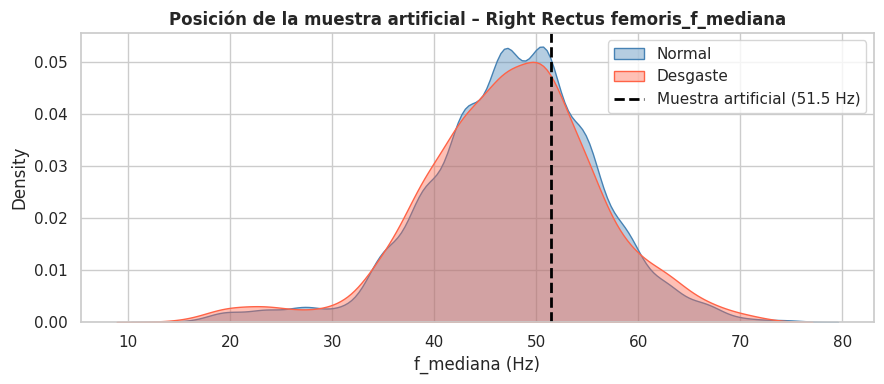

In [37]:
# Visualizar posición de la muestra artificial en la distribución real
col_vis     = f'{channels[0]}_f_mediana'
val_muestra = muestra_df[col_vis].values[0]

fig, ax = plt.subplots(figsize=(9, 4))
for clase, color, label in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Desgaste')]:
    sns.kdeplot(nuevo_df[nuevo_df['target'] == clase][col_vis],
                ax=ax, color=color, label=label, fill=True, alpha=0.4)
ax.axvline(val_muestra, color='black', linestyle='--', linewidth=2,
           label=f'Muestra artificial ({val_muestra:.1f} Hz)')
ax.set_title(f'Posición de la muestra artificial – {col_vis}', fontweight='bold')
ax.set_xlabel('f_mediana (Hz)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Resumen Final

| Etapa | Resultado clave |
|---|---|
| Dataset original | 3.002.137 muestras, 1000 Hz, 8 canales EMG, 3 sujetos, target binario |
| Feature engineering | 3.002 ventanas × 56 características (7 × 8 canales), sin solapamiento |
| EDA | f_media y f_mediana de Left Gastrocnemius medialis son las más correlacionadas con fatiga (r = -0.39) |
| Desbalance de clases | 70.9% Normal / 29.1% Desgaste → se prioriza F1 sobre Accuracy |
| Preprocesamiento | StandardScaler sobre train + split 70/15/15 estratificado |
| Mejor modelo (val) | Gradient Boosting – F1 Val = 0.7886 |
| Mejor modelo (test) | DNN – F1 Test = 0.8320 |
| Evaluación final (GB) | Accuracy=0.90, F1 macro=0.87, Recall Desgaste=0.78 |
| Prueba artificial | Clasificada como NORMAL (prob=0.80), coherente con f_mediana alta |
